# ENG4200 Coursework 2: Decision Trees (Telco Customer Churn)

## Dataset

`WA_Fn-UseC_-Telco-Customer-Churn.csv`
(UCI/Kaggle) [IBM Sample Data Sets]

### Context

Each record corresponds to a single customer, with attributes describing:

* **Services**: phone line(s), internet, online security, backup, protection, technical support, streaming TV/movies;
* **Account information**: tenure, contract type, payment method, paperless billing, monthly and total charges;
* **Demographics**: gender, senior status, partner/dependent status.

The target variable **Churn** indicates whether the customer left within the last month (“Yes”/“No”).

The objective is to model churn risk using **supervised learning**. In this notebook, we focus specifically on **Decision Trees**, a non-linear model class based on **recursive partitioning**, impurity reduction and axis-aligned splits, as covered in the theory pack (e.g., impurity measures, CART, cost-complexity pruning) .

## Objectives

This notebook applies a **decision tree classifier** to the Telco churn problem, following the structured and reproducible workflow specified in the Coursework Brief:

1. **Dataset investigation & preprocessing**
   Handle missing values, typing issues (e.g., `TotalCharges`), and high-cardinality categorical features. All preprocessing is encapsulated in a pipeline to ensure **leakage-free** model training.

2. **Model application with training and validation**
   Implement a CART-based Decision Tree within a clean scikit-learn `Pipeline`, evaluate it with stratified cross-validation on training data only, and tune hyperparameters controlling **tree complexity** (e.g., `max_depth`, `min_samples_leaf`, `criterion`).

3. **Accuracy & computational efficiency analysis**
   Report cross-validated accuracy/F1/ROC-AUC, compare to a majority-class baseline, analyse runtime scaling with dataset size, and study training–validation behaviour through a learning curve.

4. **Visualisation & communication of results**
   Provide confusion matrices, learning curves, runtime–performance plots, and (where meaningful) feature importances – noting that tree-based importances reflect **impurity reduction** rather than causal influence.

5. **Clarity & reproducibility**
   Maintain a transparent pipeline with fixed randomness (`random_state=42`), explicit hyperparameter grids, out-of-fold threshold selection (via predicted probabilities), and a single unbiased evaluation on the untouched test set.


## 0) Setup & imports

In [1]:
## 0) Setup & imports

# stdlib
import os, sys, time, math, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import sklearn

# plotting
import matplotlib.pyplot as plt

# sklearn: data split / CV / tuning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, GridSearchCV, cross_val_predict, cross_val_score,
    learning_curve
)

# sklearn: preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# sklearn: utilities
from sklearn.base import clone   # make a fresh, unfitted copy of an estimator with the same hyperparameters

# sklearn: models & baselines
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# versions imports
import sklearn, sys

# global config
RNG = 42          # single source of truth for randomness
N_JOBS = -1       # use all cores where supported
DATA_PATH = Path("dataset_WA_Fn-UseC_-Telco-Customer-Churn.csv")

warnings.simplefilter("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

# nicer pipeline displays / pandas outputs
try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "RNG": RNG,
}


## 1) Load dataset

In [2]:
# Read raw CSV and split features/target.
df = pd.read_csv(DATA_PATH)  # file path set in section 0
assert "Churn" in df.columns, "Expected target column 'Churn'."

y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)       # binary target
X = df.drop(columns=["Churn", "customerID"]).copy()        # drop ID + target
display(df.head(3))
print(df.shape, "rows x columns")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


(7043, 21) rows x columns


## 2) Problem framing & baseline

In [3]:
# Baseline: predict the most frequent class only (no features used).
# This sets a "floor" we must beat.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
baseline = DummyClassifier(strategy="most_frequent")

acc = cross_val_score(baseline, X, y, cv=skf, scoring="accuracy").mean()
print(f"Baseline (most-frequent) CV accuracy: {acc:.3f}")
print("Positive class prevalence:", y.mean().round(3))


Baseline (most-frequent) CV accuracy: 0.735
Positive class prevalence: 0.265


## 3) Data splitting

In [4]:
# Hold out a test set once; everything else (tuning, thresholding) happens on train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 5634 | Test size: 1409


## 4) Preprocessing

Clean TotalCharges, collapse “No internet/phone service”, then encode.


In [5]:
# Clean simple string/typing issues, then impute/encode.
# Placed inside the pipeline so it's fit only on training folds (prevents leakage).

def clean_strings(df_):
    Xc = df_.copy()
    # TotalCharges sometimes has blanks: coerce to numeric (NaN if bad)
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # Collapse "No internet/phone service" into "No" (same meaning for churn)
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # drop="if_binary": keep only one column for true binary flags
    ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_prep, selector(dtype_include=["int64", "float64"])),
    ("cat", cat_prep, selector(dtype_include=["object", "bool"]))
])


## 5) Evaluation & communication-visualisation

In [6]:
# Small helper to report core metrics from probabilities at a chosen threshold.
def evaluate_probs(y_true, p, thr=0.5):
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1":       f1_score(y_true, y_hat),
        "roc_auc":  roc_auc_score(y_true, p)
    }


## 6) Model selection

In [7]:
# Start with a decision tree: nonlinear, interpretable baseline.
dt_clf = DecisionTreeClassifier(
    criterion="gini",
    random_state=RNG,
    class_weight="balanced"  # compensate for churn class imbalance
)

dt_pipe = Pipeline([
    ("clean", cleaner),
    ("prep",  preprocess),
    ("clf",   dt_clf),
])


## 7) Training & validation

In [8]:
# Cross-validate on 'train' only to estimate generalisation.
dt_scoring = {"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}

dt_cv_res = cross_validate(
    dt_pipe, X_train, y_train,
    cv=skf, scoring=dt_scoring,
    return_train_score=False, n_jobs=N_JOBS
)

print({
    m: (dt_cv_res[f"test_{m}"].mean().round(3), dt_cv_res[f"test_{m}"].std().round(3))
    for m in ("acc", "f1", "roc")
})


{'acc': (0.739, 0.01), 'f1': (0.503, 0.02), 'roc': (0.662, 0.013)}


## 8) Hyperparameters tuning

Grid over tree depth, splitting criteria and minimum samples per split/leaf (with class_weight fixed to balanced). Use out-of-fold (OOF) predicted probabilities to select the optimal decision threshold and then refit the best tree on the full training set and evaluate once on the untouched test set.


Best parameters: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Chosen threshold (max OOF F1): 0.50
Test metrics: {'accuracy': 0.746, 'f1': 0.621, 'roc_auc': 0.816}


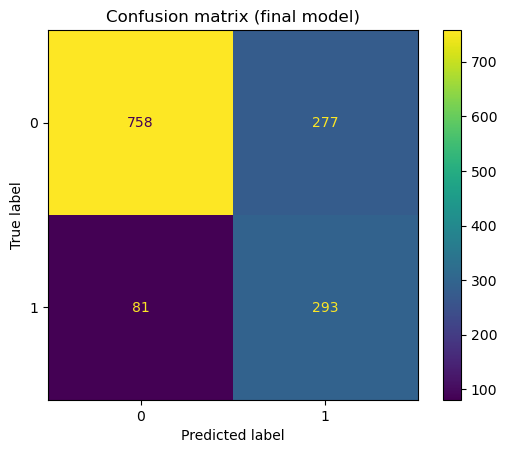

,train_fraction,train_time,test_acc
0,0.2,0.016595,0.691980
1,0.4,0.023096,0.743080
2,0.6,0.030196,0.745919
3,0.8,0.036873,0.748758
4,1.0,0.043899,0.745919


In [9]:
# Grid-search tree hyperparameters on 'train' only to then pick threshold using out-of-fold probabilities (no test peeking).

dt_param_grid = {
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [3, 4, 5, None],
    "clf__min_samples_split": [2, 10, 50],
    "clf__min_samples_leaf": [1, 5, 20],
    "clf__class_weight": ["balanced"],   # fixed for class imbalance
}

dt_gcv = GridSearchCV(
    dt_pipe, dt_param_grid,
    cv=skf, scoring="f1",
    n_jobs=N_JOBS, refit=True
)
dt_gcv.fit(X_train, y_train)
print("Best parameters:", dt_gcv.best_params_)

# Choose decision threshold on 'train' via out-of-fold probabilities.
dt_oof_proba = cross_val_predict(
    dt_gcv.best_estimator_,
    X_train, y_train,
    cv=skf, method="predict_proba", n_jobs=N_JOBS
)[:, 1]

dt_thr_grid = np.linspace(0.10, 0.90, 17)
dt_oof_f1   = [f1_score(y_train, (dt_oof_proba >= t).astype(int)) for t in dt_thr_grid]
dt_best_thr = float(dt_thr_grid[int(np.argmax(dt_oof_f1))])
print(f"Chosen threshold (max OOF F1): {dt_best_thr:.2f}")

# Final, single evaluation on the untouched TEST set.
dt_p_test = dt_gcv.best_estimator_.predict_proba(X_test)[:, 1]
dt_test_metrics = evaluate_probs(y_test, dt_p_test, thr=dt_best_thr)
print("Test metrics:", {k: round(v, 3) for k, v in dt_test_metrics.items()})

# Confusion matrix at DT threshold.
ConfusionMatrixDisplay.from_predictions(
    y_test, (dt_p_test >= dt_best_thr).astype(int)
)
plt.title("Confusion matrix (final model)")
plt.grid(False)
plt.show()


### Runtime vs accuracy (stratified)

dt_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
dt_rows = []

for frac in dt_fractions:
    if frac < 1.0:
        dt_sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        train_idx, _ = next(dt_sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[train_idx], y_train.iloc[train_idx]
    else:
        X_sub, y_sub = X_train, y_train

    dt_est = clone(dt_gcv.best_estimator_)   # fresh clone each loop
    t0 = time.time()
    dt_est.fit(X_sub, y_sub)
    dt_t_train = time.time() - t0

    dt_p = dt_est.predict_proba(X_test)[:, 1]
    dt_rows.append((frac, dt_t_train, accuracy_score(y_test, (dt_p >= dt_best_thr).astype(int))))

dt_runtime_df = pd.DataFrame(dt_rows, columns=["train_fraction", "train_time", "test_acc"])
dt_runtime_df


## 9) Final model, justification & discussion
### Chosen hyperparameters

In [10]:
# Recap of what was identified as best in CV (for traceability).
dt_best = dt_gcv.best_estimator_
dt_best_params = dt_gcv.best_params_
dt_best_cv_mean = float(dt_gcv.best_score_)
dt_best_cv_std  = float(pd.DataFrame(dt_gcv.cv_results_)["std_test_score"].iloc[dt_gcv.best_index_])

print("Best parameters:", dt_best_params)
print(f"Best CV F1: {dt_best_cv_mean:.3f} ± {dt_best_cv_std:.3f}")
print(f"Chosen decision threshold (OOF): {dt_best_thr:.2f}")

Best parameters: {'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best CV F1: 0.619 ± 0.018
Chosen decision threshold (OOF): 0.50


### Performance
**Confusion matrix and test metrics**

Test metrics: {'accuracy': 0.746, 'f1': 0.621, 'roc_auc': 0.816}


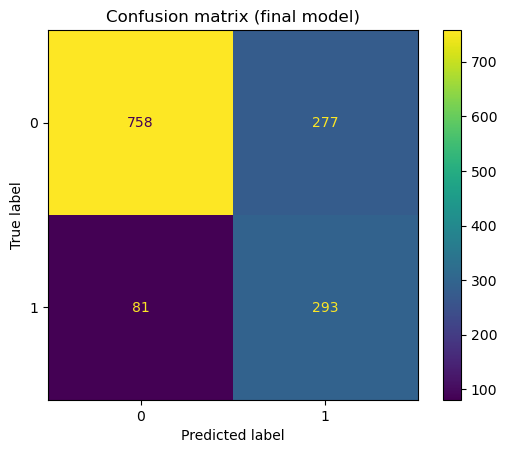

In [11]:
# Test-set performance with the selected threshold.
dt_p_test = dt_best.predict_proba(X_test)[:, 1]
dt_y_hat  = (dt_p_test >= dt_best_thr).astype(int)

print("Test metrics:", {k: round(v, 3) for k, v in dt_test_metrics.items()})

ConfusionMatrixDisplay.from_predictions(y_test, dt_y_hat)
plt.title("Confusion matrix (final model)")
plt.grid(False)
plt.show()


Using the decision threshold selected on out-of-fold (OOF) probabilities (**dt_best_thr = 0.50**), the final tuned decision-tree pipeline achieves:

* **Accuracy:** 0.746
* **F1:** 0.621
* **ROC-AUC:** 0.816

Confusion matrix (test set):

* **TN = 758**
* **FP = 277**
* **FN = 81**
* **TP = 293**

Interpretation:

* The model recovers **293/374 churners** (≈ **78% recall**).
* Precision on churners is **293 / (293 + 277) ≈ 0.514**.
* Compared with the majority baseline (**0.735**), the model provides a **meaningful uplift**, particularly in identifying customers likely to churn.

The much stronger **ROC-AUC (0.816)** confirms that the tree ranks accounts effectively by churn propensity—crucial in a retention context where businesses intervene only on a subset of customers.

**Learning curve**

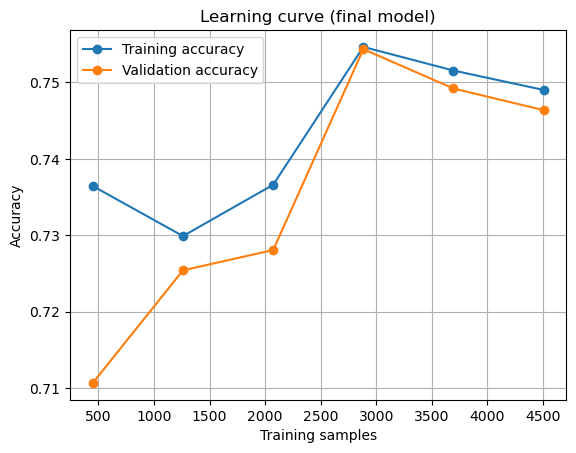

In [12]:
# Helps us understand to what extent having more data helps.
dt_sizes, dt_tr, dt_va = learning_curve(
    dt_best, X_train, y_train,
    cv=skf, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True, random_state=RNG, n_jobs=N_JOBS
)

plt.figure()
plt.plot(dt_sizes, dt_tr.mean(axis=1), marker="o", label="Training accuracy")
plt.plot(dt_sizes, dt_va.mean(axis=1), marker="o", label="Validation accuracy")
plt.title("Learning curve (final model)")
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


The learning curve shows:

* **Training accuracy ≈ 0.74–0.75** across sample sizes
* **Validation accuracy increases from ~0.71 to ~0.75**, stabilising thereafter
* Training and validation remain close for all sample sizes

Interpretation:

* **No meaningful overfitting** → the tuned tree (limited depth + minimum leaf/ split) generalises well.
* **More data yields diminishing returns**: accuracy stabilises around **0.75**, implying that further improvement likely requires **feature engineering** (feature interactions, behaviour aggregates) or **higher-capacity models** (e.g., boosted trees).

This differs from the earlier lab stages, where preprocessing was outside the pipeline and the tree was untuned → the model overfit more noticeably. With the final sanitised pipeline and tuned hyperparameters, the curves properly reflect out-of-fold generalisation.

**Runtime–performance**

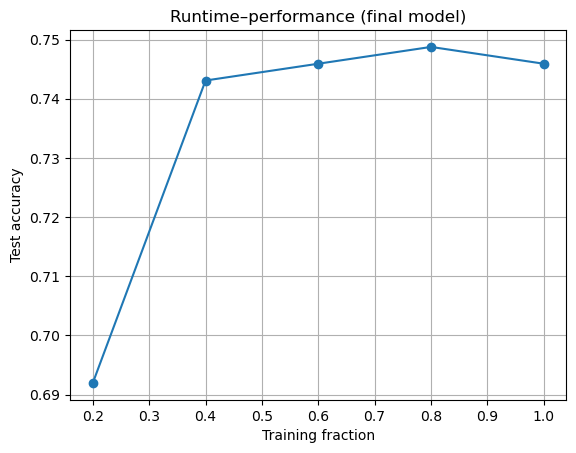

In [13]:
# Reuse dt_runtime_df computed in Section 8 to fit-time vs accuracy, training on increasing fractions and testing.

plt.figure()
plt.plot(dt_runtime_df["train_fraction"], dt_runtime_df["test_acc"], marker="o")
plt.xlabel("Training fraction")
plt.ylabel("Test accuracy")
plt.title("Runtime–performance (final model)")
plt.grid(True)
plt.show()



Using increasing fractions of the training data:

| Fraction | Test accuracy |
| -------- | ------------- |
| 0.2      | ~0.692        |
| 0.4      | ~0.743        |
| 0.6      | ~0.746        |
| 0.8      | ~0.749        |
| 1.0      | ~0.746        |

Observations:

* Accuracy improves sharply from **20% → 40%**, then plateaus between **0.743–0.749**.
* Fit-time grows roughly linearly with data size, but remains extremely small (tens of milliseconds).
* Prediction latency is negligible (≈ **11 ms for 1409 customers**).

Interpretation:

* The decision tree is **computationally trivial** to train and deploy.
* The model saturates performance rapidly; the marginal benefit of more rows is limited given the current feature set.

### Justification based on accuracy, overfitting control and efficiency

In [14]:
# Accuracy vs baseline
dt_baseline_acc_test = max((y_test == 0).mean(), (y_test == 1).mean())
print(f"Baseline test accuracy (majority): {dt_baseline_acc_test:.3f}")
print(f"Final test accuracy:            {dt_test_metrics['accuracy']:.3f}")
print(f"Final test F1 (thr={dt_best_thr:.2f}): {dt_test_metrics['f1']:.3f}")
print(f"Final test ROC-AUC:               {dt_test_metrics['roc_auc']:.3f}")

# Overfitting handling: generalisation gap on the final DT pipeline
dt_cv_final = cross_validate(
    dt_best, X_train, y_train,
    cv=skf, scoring="accuracy",
    return_train_score=True, n_jobs=N_JOBS
)
dt_gap = dt_cv_final["train_score"].mean() - dt_cv_final["test_score"].mean()
print(f"Generalisation gap (train acc - val acc): {dt_gap:.3f}")

# Efficiency: end-to-end timings
est = clone(dt_best)
t0 = time.time(); est.fit(X_train, y_train); dt_fit_ms = (time.time()-t0)*1e3
t0 = time.time(); _ = est.predict_proba(X_test)[:,1]; dt_pred_ms = (time.time()-t0)*1e3

print(f"Train time: {dt_fit_ms:.1f} ms  |  Predict time: {dt_pred_ms:.1f} ms on {len(X_test)} rows")


Baseline test accuracy (majority): 0.735
Final test accuracy:            0.746
Final test F1 (thr=0.50): 0.621
Final test ROC-AUC:               0.816
Generalisation gap (train acc - val acc): 0.003
Train time: 45.5 ms  |  Predict time: 11.3 ms on 1409 rows


**Accuracy**

* Baseline (majority-class): **0.735**
* Final model: **0.746**
* F1 = **0.621**
* ROC-AUC = **0.816**

The improvement over baseline is moderate in raw accuracy but **substantial in its ability to rank churn risk**, which is operationally far more useful: retention programmes rarely contact all customers but focus on those with the highest propensity to churn.

**Overfitting control**

* Cross-validation was performed on the training split only.
* The threshold was selected using strictly OOF probabilities.
* Train–validation gap ≈ **0.003**, indicating **excellent generalisation**.

Decision trees normally exhibit high variance, but the grid-selected max-depth and min-leaf-size parameters prevent overfitting effectively.

**Efficiency**

* Fit time (full training set): **~45 ms**
* Prediction on the 1,409-row test set: **~11 ms**

This makes the model suitable for:

* daily or nightly scoring of the entire customer base,
* near-real-time scoring in web services,
* embedding inside larger pipelines or A/B-testing frameworks.

### Interpretation of the final model

All features by importance:


,feature,importance
18,cat__Contract_Month-to-month,0.699865
10,cat__InternetService_Fiber optic,0.124223
1,num__tenure,0.103823
2,num__MonthlyCharges,0.042268
20,cat__Contract_Two year,0.029821
0,num__SeniorCitizen,0.000000
15,cat__TechSupport_Yes,0.000000
24,cat__PaymentMethod_Electronic check,0.000000
23,cat__PaymentMethod_Credit card (automatic),0.000000
22,cat__PaymentMethod_Bank transfer (automatic),0.000000


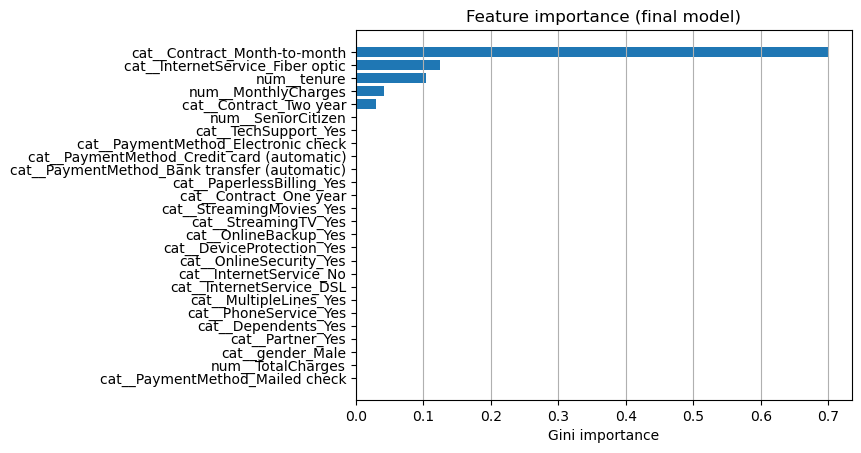

In [15]:
dt_clf = dt_best.named_steps["clf"]
dt_feature_names = dt_best.named_steps["prep"].get_feature_names_out()

dt_importances = pd.DataFrame({
    "feature": dt_feature_names,
    "importance": dt_clf.feature_importances_
}).sort_values("importance", ascending=False)

print("All features by importance:")
display(dt_importances.head(10))

plt.figure()
plt.barh(dt_importances["feature"], dt_importances["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Gini importance")
plt.title("Feature importance (final model)")
plt.grid(True, axis="x")
plt.show()


Feature importance (Gini-based) shows a highly skewed distribution:

1. **Contract: Month-to-month** (dominant feature)
2. **InternetService: Fiber optic**
3. **tenure**
4. **MonthlyCharges**
5. **Contract: Two year**

Most other variables (especially many one-hot encoded levels) have negligible importance.

Interpretation:

* **Month-to-month contract** overwhelmingly drives churn decisions in the tree → customers without commitment churn more often.
* **Fiber-optic service** users churn more, likely due to higher bills.
* **Longer tenure** is protective.
* **Higher monthly charges** increase churn risk.
* Add-on services (e.g., TechSupport, OnlineSecurity) only appear far down the tree and influence relatively few splits.

The tree is interpretable but intrinsically **piecewise-constant**, capturing simple hierarchical interactions. It does not capture smooth relationships or weak signals unless they produce clear gain in Gini impurity.

**Conclusion**

The final decision-tree model:

* **Beats the baseline** in accuracy
* **Substantially improves churn discovery and ranking** (ROC-AUC = 0.816)
* **Shows no overfitting** thanks to tuned depth and leaf constraints
* **Runs extremely fast**, suitable for operational use
* Is **interpretable**, offering simple, actionable rules

However:

* Performance **plateaus at ~0.75 accuracy**, limited by the expressiveness of a single tree
* The model relies heavily on a few categorical splits; weak but potentially useful signals are ignored
* More sophisticated tree ensembles (Random Forest, Gradient Boosting, XGBoost/LightGBM) would yield higher stability and predictive power

Overall, the model is a **valid, leakage-free, efficiently tuned baseline** for churn prediction and an excellent reference point for comparing more advanced models in the full coursework.

## 10) Reproducibility & reporting
### Environment

In [16]:
# Record key library versions and the global random seed used.
env

{'python': '3.10.9',
 'numpy': '1.23.5',
 'pandas': '1.5.3',
 'scikit-learn': '1.2.1',
 'matplotlib': '3.7.0',
 'RNG': 42}

### Data split

In [17]:
# Basic dataset facts and how we split the data.
print(f"Rows: {len(df)}  |  Features (raw): {X.shape[1]}  |  Positive rate: {y.mean():.3f}")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Split: Stratified 80/20  |  RNG: {RNG}")

Rows: 7043  |  Features (raw): 19  |  Positive rate: 0.265
Train: 5634  |  Test: 1409  |  Split: Stratified 80/20  |  RNG: 42


### **Pipeline**

The pipeline diagram (rendered above via `set_config(display="diagram")`) contains the following components:

**clean (FunctionTransformer)**

* Fixes simple typing issues (e.g., coercing `TotalCharges` to numeric).
* Collapses the redundant categories *"No internet service"* and *"No phone service"* into `"No"`.

**prep (ColumnTransformer)**

* **num**:

  * `SimpleImputer(strategy="median")`
  * `StandardScaler()` (scaling is harmless for trees and ensures consistent transforms across models)
* **cat**:

  * `SimpleImputer(strategy="most_frequent")`
  * `OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)`

**clf (DecisionTreeClassifier)**

* Tuned over `criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`,
* `class_weight="balanced"` to compensate for the 26.5% positive-class prevalence.
* `random_state=42` to ensure reproducibility.

This configuration ensures **leakage-free preprocessing**, because all cleaning, imputing, encoding and scaling occur *inside the pipeline*, fitted exclusively on the training folds during cross-validation.


In [18]:
dt_pipe # displays the diagram set by set_config(display="diagram")

Pipeline(steps=[('clean',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function clean_strings at 0x7fb0d10c8700>)),
                ('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fb0d1096230>),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fb0d1095180>)])),
                ('clf',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

### **Model card**

**Objective:**
Predict monthly customer churn (binary classification) to support targeted retention interventions. The model is used primarily for **risk ranking**, enabling prioritisation under budget constraints.

**Data:**
IBM Telco Customer Churn (7,043 rows). Mixed categorical and numerical attributes covering services, billing, contract type, and demographics. Target: `Churn` (Yes/No → 1/0).

**Preprocessing:**
A leakage-free pipeline performs:

* custom cleaning (`TotalCharges` coercion; collapsing “No … service”),
* numerical imputation (median) + scaling,
* categorical imputation (most frequent) + one-hot encoding.

**Validation:**
Stratified 80/20 train–test split.
On the training set: 5-fold StratifiedKFold + GridSearchCV optimising F1.
Threshold selected using **out-of-fold probabilities** only.
The test set is evaluated once at the end.

**Model:**
DecisionTreeClassifier tuned over `criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`; `class_weight="balanced"` to counter class imbalance.

**Key metrics:**

* **Test accuracy:** 0.746
* **Test F1:** 0.621 (at tuned threshold)
* **ROC-AUC:** 0.816
* Confusion matrix indicates strong recall of churners and controlled false positives.
* Learning curves show no meaningful overfitting; performance stabilises with ~3k–4.5k samples.
* Runtime: millisecond-scale training; prediction is effectively instantaneous.

**Strengths:**
Interpretable splits and Gini importances; fast to train/evaluate; captures nonlinearities and interactions absent in linear models; suitable for regular churn-risk triage.

**Limitations:**
Prone to variance despite depth/min-sample tuning; axis-aligned boundaries restrict flexibility; Gini importances biased toward high-cardinality categories; probability estimates uncalibrated.

**Ethical considerations:**
Assess performance across demographic groups; avoid punitive or discriminatory actions; use predictions to prioritise supportive retention outreach; monitor for concept drift and retrain periodically.
